# House Price Prediction
This notebook implements a linear regression model to predict the prices of houses based on their square footage and the number of bedrooms and bathrooms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [ ]:


train_data['TotalBathrooms'] = train_data['FullBath'] + 0.5 * train_data['HalfBath']
test_data['TotalBathrooms'] = test_data['FullBath'] + 0.5 * test_data['HalfBath']

features = ['GrLivArea', 'BedroomAbvGr', 'TotalBathrooms']
target = 'SalePrice'

X = train_data[features]
y = train_data[target]


print("Missing values in features:")
print(X.isnull().sum())

Missing values in features:
GrLivArea         0
BedroomAbvGr      0
TotalBathrooms    0
dtype: int64


In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R^2 Score: {r2:.4f}')

Root Mean Squared Error: 53371.56
R^2 Score: 0.6286


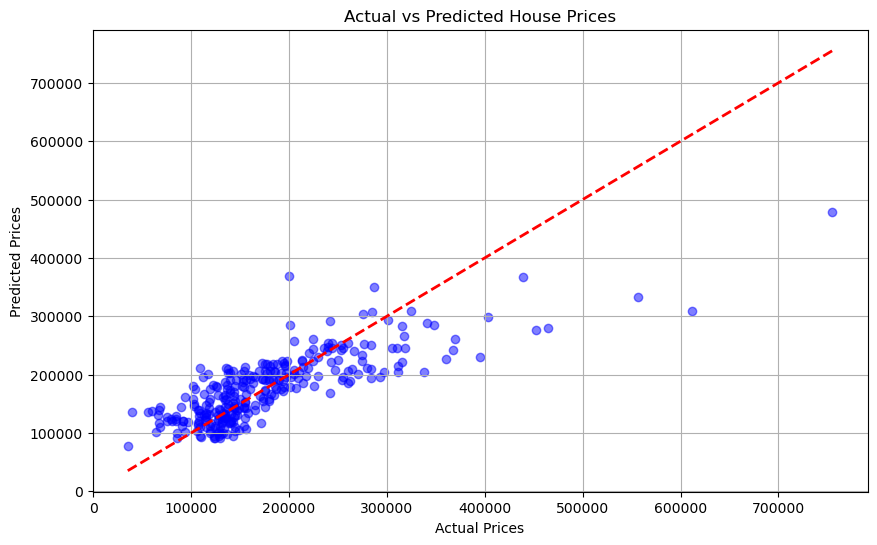

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.5, color='blue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.grid(True)
plt.show()

In [ ]:
X_test = test_data[features]
X_test = X_test.fillna(X_test.median())

test_predictions = model.predict(X_test)

submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission successfully saved to submission.csv")
submission.head()

Submission successfully saved to submission.csv


,Id,SalePrice
0,1461,120825.378340
1,1462,151297.225323
2,1463,208571.501610
3,1464,206055.579229
4,1465,186553.153828
